##Section A — Install and imports

In [51]:
!pip -q install transformers accelerate sentencepiece

In [52]:
import json
from collections import defaultdict
from dataclasses import dataclass, asdict

import torch
import torch.nn as nn
from transformers import AutoConfig, AutoModelForCausalLM

## Section B — Load models

In [53]:
MODEL_IDS = [
    "openai-community/gpt2",
    "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
]

In [54]:
def get_device():
    return "cuda" if torch.cuda.is_available() else "cpu"

DEVICE = get_device()
print("Device:", DEVICE)

Device: cuda


In [55]:
def load_config(model_id):
    return AutoConfig.from_pretrained(model_id)

def load_model(model_id):
    kwargs = {"low_cpu_mem_usage": True}

    if DEVICE == "cuda":
        kwargs["torch_dtype"] = torch.float16
        kwargs["device_map"] = "auto"
    else:
        kwargs["torch_dtype"] = torch.float32

    model = AutoModelForCausalLM.from_pretrained(model_id, **kwargs)
    model.eval()
    return model

In [56]:
configs = {}
models = {}

for model_id in MODEL_IDS:
    print(f"Loading config for {model_id} ...")
    configs[model_id] = load_config(model_id)

for model_id in MODEL_IDS:
    print(f"Loading model for {model_id} ...")
    models[model_id] = load_model(model_id)

Loading config for openai-community/gpt2 ...
Loading config for TinyLlama/TinyLlama-1.1B-Chat-v1.0 ...
Loading model for openai-community/gpt2 ...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading model for TinyLlama/TinyLlama-1.1B-Chat-v1.0 ...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

##Section C — Build generic parser

###Helper functions

In [57]:
def count_parameters(module):
    return sum(p.numel() for p in module.parameters())

def count_trainable_parameters(module):
    return sum(p.numel() for p in module.parameters() if p.requires_grad)

def module_param_shapes(module):
    shapes = {}
    for name, p in module.named_parameters(recurse=False):
        shapes[name] = list(p.shape)
    return shapes

###Recursive parser

In [58]:
def parse_module_tree(module, name="root", depth=0, max_depth=None):
    children = list(module.named_children())

    node = {
        "name": name,
        "type": module.__class__.__name__,
        "depth": depth,
        "num_direct_params": sum(p.numel() for p in module.parameters(recurse=False)),
        "num_total_params": sum(p.numel() for p in module.parameters()),
        "parameter_shapes": module_param_shapes(module),
        "children": []
    }

    if max_depth is not None and depth >= max_depth:
        return node

    for child_name, child_module in children:
        child_node = parse_module_tree(
            child_module,
            name=child_name,
            depth=depth + 1,
            max_depth=max_depth
        )
        node["children"].append(child_node)

    return node

###config-level summary

In [59]:
def config_summary(config):
    keys = [
        "model_type",
        "architectures",
        "hidden_size",
        "intermediate_size",
        "num_hidden_layers",
        "num_attention_heads",
        "num_key_value_heads",
        "vocab_size",
        "max_position_embeddings",
        "hidden_act",
        "rms_norm_eps",
        "layer_norm_epsilon",
        "tie_word_embeddings",
    ]

    summary = {}
    config_dict = config.to_dict()
    for key in keys:
        if key in config_dict:
            summary[key] = config_dict[key]
    return summary

###infer family

In [60]:
def infer_family(config):
    model_type = getattr(config, "model_type", "").lower()
    if "gpt2" in model_type:
        return "gpt2"
    if "llama" in model_type:
        return "llama"
    if "phi" in model_type:
        return "phi"
    return "unknown"

###classify module

---



In [61]:
def classify_module(name, module):
    """
    Return one semantic label for a module name.
    Priority matters: more specific rules should come first.
    """
    lname = name.lower()
    mtype = module.__class__.__name__.lower()

    # -----------------------
    # 1) Norms first
    # -----------------------
    norm_suffixes = (
        "ln_1", "ln_2", "ln_f",
        "input_layernorm", "post_attention_layernorm", "norm"
    )
    if lname.endswith(norm_suffixes) or "layernorm" in mtype or "rmsnorm" in mtype:
        return "norm"

    # -----------------------
    # 2) Embeddings
    # -----------------------
    embedding_suffixes = ("wte", "wpe", "embed_tokens")
    if lname.endswith(embedding_suffixes) or "embedding" in mtype:
        return "embedding"

    # -----------------------
    # 3) Positional / rotary
    # -----------------------
    if "rotary_emb" in lname or "rotaryembedding" in mtype:
        return "positional"

    # -----------------------
    # 4) Attention projections
    # -----------------------
    attention_projection_suffixes = (
        "c_attn", "c_proj",   # GPT-2
        "q_proj", "k_proj", "v_proj", "o_proj"  # Llama-style
    )
    if lname.endswith(attention_projection_suffixes):
        # disambiguate GPT-2 c_proj: it can appear in attn and mlp
        if ".attn." in lname or ".self_attn." in lname:
            return "attention_projection"
        if lname.endswith(("q_proj", "k_proj", "v_proj", "o_proj")):
            return "attention_projection"

    # -----------------------
    # 5) Attention containers
    # -----------------------
    attention_container_suffixes = ("attn", "self_attn")
    if lname.endswith(attention_container_suffixes):
        return "attention_container"

    # -----------------------
    # 6) Attention support modules
    # -----------------------
    attention_support_suffixes = ("attn_dropout", "resid_dropout")
    if lname.endswith(attention_support_suffixes):
        return "attention_support"

    # -----------------------
    # 7) MLP projections
    # -----------------------
    mlp_projection_suffixes = (
        "c_fc", "gate_proj", "up_proj", "down_proj"
    )
    if lname.endswith(mlp_projection_suffixes):
        return "mlp_projection"

    # GPT-2 c_proj can also be an MLP projection
    if lname.endswith("c_proj") and ".mlp." in lname:
        return "mlp_projection"

    # -----------------------
    # 8) MLP containers / support
    # -----------------------
    if lname.endswith("mlp"):
        return "mlp_container"

    if lname.endswith(("act", "act_fn", "dropout")) and ".mlp." in lname:
        return "mlp_support"

    # -----------------------
    # 9) Decoder block containers
    # -----------------------
    if mtype in ("gpt2block", "llamadecoderlayer"):
        return "decoder_block"

    if mtype == "modulelist" and (lname.endswith(".h") or lname.endswith(".layers")):
        return "decoder_block_container"

    # -----------------------
    # 10) LM head
    # -----------------------
    if lname.endswith("lm_head"):
        return "lm_head"

    return "other"

###normalized architecture summary

In [62]:
def normalized_architecture_summary(model, config):
    family = infer_family(config)

    summary = {
        "family": family,
        "top_level_modules": [],
        "block_container": None,
        "num_blocks_detected": 0,
        "embedding_modules": [],
        "positional_modules": [],
        "norm_modules": [],
        "attention_containers": [],
        "attention_projections": [],
        "attention_support_modules": [],
        "mlp_containers": [],
        "mlp_projections": [],
        "mlp_support_modules": [],
        "decoder_blocks": [],
        "lm_head_modules": [],
        "other_modules_sample": [],
        "lm_head_present": hasattr(model, "lm_head"),
    }

    # top-level modules
    for name, module in model.named_children():
        summary["top_level_modules"].append((name, module.__class__.__name__))

    # detect block container
    for candidate in ["transformer.h", "model.layers", "layers", "h"]:
        obj = model
        ok = True
        for part in candidate.split("."):
            if hasattr(obj, part):
                obj = getattr(obj, part)
            else:
                ok = False
                break
        if ok and isinstance(obj, (nn.ModuleList, list, tuple)):
            summary["block_container"] = candidate
            summary["num_blocks_detected"] = len(obj)
            break

    # classify every named module
    for name, module in model.named_modules():
        if name == "":
            continue

        category = classify_module(name, module)

        if category == "embedding":
            summary["embedding_modules"].append(name)
        elif category == "positional":
            summary["positional_modules"].append(name)
        elif category == "norm":
            summary["norm_modules"].append(name)
        elif category == "attention_container":
            summary["attention_containers"].append(name)
        elif category == "attention_projection":
            summary["attention_projections"].append(name)
        elif category == "attention_support":
            summary["attention_support_modules"].append(name)
        elif category == "mlp_container":
            summary["mlp_containers"].append(name)
        elif category == "mlp_projection":
            summary["mlp_projections"].append(name)
        elif category == "mlp_support":
            summary["mlp_support_modules"].append(name)
        elif category == "decoder_block":
            summary["decoder_blocks"].append(name)
        elif category == "lm_head":
            summary["lm_head_modules"].append(name)
        else:
            if len(summary["other_modules_sample"]) < 20:
                summary["other_modules_sample"].append(name)

    return summary

###pretty-printer

In [63]:
def pretty_print_tree(node, indent=0, max_children=20):
    prefix = "  " * indent
    print(f"{prefix}- {node['name']} [{node['type']}] "
          f"(direct={node['num_direct_params']:,}, total={node['num_total_params']:,})")

    children = node["children"]
    for i, child in enumerate(children):
        if i >= max_children:
            print(f"{prefix}  ... ({len(children) - max_children} more children)")
            break
        pretty_print_tree(child, indent + 1, max_children=max_children)

###parser

In [64]:
parsed_trees = {}
normalized_summaries = {}

for model_id in MODEL_IDS:
    print("=" * 100)
    print("MODEL:", model_id)

    config = configs[model_id]
    model = models[model_id]

    print("\nCONFIG SUMMARY")
    print(json.dumps(config_summary(config), indent=2))

    normalized_summaries[model_id] = normalized_architecture_summary(model, config)
    print("\nNORMALIZED ARCHITECTURE SUMMARY")
    print(json.dumps(normalized_summaries[model_id], indent=2, default=str))

    parsed_trees[model_id] = parse_module_tree(model, name=model_id, max_depth=3)
    print("\nMODULE TREE (depth=3)")
    pretty_print_tree(parsed_trees[model_id])

MODEL: openai-community/gpt2

CONFIG SUMMARY
{
  "model_type": "gpt2",
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "vocab_size": 50257,
  "layer_norm_epsilon": 1e-05,
  "tie_word_embeddings": true
}

NORMALIZED ARCHITECTURE SUMMARY
{
  "family": "gpt2",
  "top_level_modules": [
    [
      "transformer",
      "GPT2Model"
    ],
    [
      "lm_head",
      "Linear"
    ]
  ],
  "block_container": "transformer.h",
  "num_blocks_detected": 12,
  "embedding_modules": [
    "transformer.wte",
    "transformer.wpe"
  ],
  "positional_modules": [],
  "norm_modules": [
    "transformer.h.0.ln_1",
    "transformer.h.0.ln_2",
    "transformer.h.1.ln_1",
    "transformer.h.1.ln_2",
    "transformer.h.2.ln_1",
    "transformer.h.2.ln_2",
    "transformer.h.3.ln_1",
    "transformer.h.3.ln_2",
    "transformer.h.4.ln_1",
    "transformer.h.4.ln_2",
    "transformer.h.5.ln_1",
    "transformer.h.5.ln_2",
    "transformer.h.6.ln_1",
    "transformer.h.6.ln_2",
    "transformer.h.7.ln_1",
    

In [65]:
with open("parsed_model_trees.json", "w") as f:
    json.dump(parsed_trees, f, indent=2)

with open("normalized_architecture_summaries.json", "w") as f:
    json.dump(normalized_summaries, f, indent=2, default=str)

In [66]:
clean_summaries = {}

for model_id in MODEL_IDS:
    print("=" * 100)
    print("MODEL:", model_id)
    clean_summaries[model_id] = normalized_architecture_summary(models[model_id], configs[model_id])
    print(json.dumps(clean_summaries[model_id], indent=2))

MODEL: openai-community/gpt2
{
  "family": "gpt2",
  "top_level_modules": [
    [
      "transformer",
      "GPT2Model"
    ],
    [
      "lm_head",
      "Linear"
    ]
  ],
  "block_container": "transformer.h",
  "num_blocks_detected": 12,
  "embedding_modules": [
    "transformer.wte",
    "transformer.wpe"
  ],
  "positional_modules": [],
  "norm_modules": [
    "transformer.h.0.ln_1",
    "transformer.h.0.ln_2",
    "transformer.h.1.ln_1",
    "transformer.h.1.ln_2",
    "transformer.h.2.ln_1",
    "transformer.h.2.ln_2",
    "transformer.h.3.ln_1",
    "transformer.h.3.ln_2",
    "transformer.h.4.ln_1",
    "transformer.h.4.ln_2",
    "transformer.h.5.ln_1",
    "transformer.h.5.ln_2",
    "transformer.h.6.ln_1",
    "transformer.h.6.ln_2",
    "transformer.h.7.ln_1",
    "transformer.h.7.ln_2",
    "transformer.h.8.ln_1",
    "transformer.h.8.ln_2",
    "transformer.h.9.ln_1",
    "transformer.h.9.ln_2",
    "transformer.h.10.ln_1",
    "transformer.h.10.ln_2",
    "transforme

In [67]:
def summarize_category_counts(summary):
    keys = [
        "embedding_modules",
        "positional_modules",
        "norm_modules",
        "attention_containers",
        "attention_projections",
        "attention_support_modules",
        "mlp_containers",
        "mlp_projections",
        "mlp_support_modules",
        "decoder_blocks",
        "lm_head_modules",
    ]
    return {k: len(summary[k]) for k in keys}

for model_id, summary in clean_summaries.items():
    print(model_id)
    print(json.dumps(summarize_category_counts(summary), indent=2))
    print()

openai-community/gpt2
{
  "embedding_modules": 2,
  "positional_modules": 0,
  "norm_modules": 25,
  "attention_containers": 12,
  "attention_projections": 24,
  "attention_support_modules": 24,
  "mlp_containers": 12,
  "mlp_projections": 24,
  "mlp_support_modules": 24,
  "decoder_blocks": 12,
  "lm_head_modules": 1
}

TinyLlama/TinyLlama-1.1B-Chat-v1.0
{
  "embedding_modules": 2,
  "positional_modules": 0,
  "norm_modules": 45,
  "attention_containers": 22,
  "attention_projections": 88,
  "attention_support_modules": 0,
  "mlp_containers": 22,
  "mlp_projections": 66,
  "mlp_support_modules": 22,
  "decoder_blocks": 22,
  "lm_head_modules": 1
}



##Section D — Hierarchical representation from JSON

In [68]:
import json
import math
import re
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import display, Markdown

# ------------------------------------------------------------
# Load JSON artifacts
# ------------------------------------------------------------
def load_first_existing(candidate_paths):
    for p in candidate_paths:
        p = Path(p)
        if p.exists():
            with open(p, "r") as f:
                return json.load(f), str(p)
    raise FileNotFoundError(
        f"None of these files were found: {candidate_paths}"
    )

parsed_trees, parsed_trees_path = load_first_existing([
    "parsed_model_trees.json"
])

normalized_summaries, normalized_summaries_path = load_first_existing([
    "normalized_architecture_summaries_clean.json",
    "clean_summaries.json",
    "normalized_architecture_summaries.json"
])

# Optional: use config summaries if you saved them separately
config_summaries = {}
for p in ["config_summaries.json"]:
    if Path(p).exists():
        with open(p, "r") as f:
            config_summaries = json.load(f)
        break

model_ids = [mid for mid in parsed_trees.keys() if mid in normalized_summaries]

display(Markdown(
    f"Loaded **{len(model_ids)} models** from:\n\n"
    f"- Parsed trees: `{parsed_trees_path}`\n"
    f"- Normalized summaries: `{normalized_summaries_path}`"
))

# ------------------------------------------------------------
# Generic helpers
# ------------------------------------------------------------
def model_label(model_id):
    return model_id.split("/")[-1]

def format_params(n):
    n = int(n)
    if n >= 1_000_000_000:
        return f"{n / 1_000_000_000:.2f}B"
    if n >= 1_000_000:
        return f"{n / 1_000_000:.2f}M"
    if n >= 1_000:
        return f"{n / 1_000:.1f}K"
    return str(n)

def find_node_by_path(tree, path):
    """
    Path is relative to the root, e.g. 'transformer.h' or 'model.layers'
    """
    if not path:
        return tree

    node = tree
    for part in path.split("."):
        found = None
        for child in node.get("children", []):
            if child["name"] == part:
                found = child
                break
        if found is None:
            return None
        node = found
    return node

def collect_node_types(node):
    types = [node.get("type", "Unknown")]
    for child in node.get("children", []):
        types.extend(collect_node_types(child))
    return types

def summary_list(summary, key, fallback=None):
    val = summary.get(key, fallback if fallback is not None else [])
    return val if isinstance(val, list) else []

def normalize_top_level_modules(summary):
    tops = summary.get("top_level_modules", [])
    out = []
    for item in tops:
        if isinstance(item, (list, tuple)) and len(item) == 2:
            out.append((item[0], item[1]))
    return out

# ------------------------------------------------------------
# Robust semantic extraction from either old or cleaned schema
# ------------------------------------------------------------
def get_embedding_modules(summary):
    names = summary_list(summary, "embedding_modules")
    return list(dict.fromkeys(names))

def get_positional_modules(summary):
    if "positional_modules" in summary:
        return list(dict.fromkeys(summary_list(summary, "positional_modules")))
    # fallback for older summaries
    candidates = get_embedding_modules(summary)
    extra = []
    for n in candidates:
        lname = n.lower()
        if "wpe" in lname or "rotary" in lname or "position" in lname:
            extra.append(n)
    # also search broader summary lists if needed
    for key, val in summary.items():
        if isinstance(val, list):
            for x in val:
                if isinstance(x, str):
                    lx = x.lower()
                    if "rotary" in lx or "position" in lx:
                        extra.append(x)
    return list(dict.fromkeys(extra))

def get_norm_modules(summary):
    return list(dict.fromkeys(summary_list(summary, "norm_modules")))

def get_attention_containers(summary):
    if "attention_containers" in summary:
        return list(dict.fromkeys(summary_list(summary, "attention_containers")))
    old = summary_list(summary, "attention_modules")
    out = []
    for n in old:
        lname = n.lower()
        if lname.endswith(".attn") or lname.endswith(".self_attn"):
            out.append(n)
    return list(dict.fromkeys(out))

def get_attention_projections(summary):
    if "attention_projections" in summary:
        return list(dict.fromkeys(summary_list(summary, "attention_projections")))
    old = summary_list(summary, "attention_modules")
    out = []
    for n in old:
        lname = n.lower()
        if lname.endswith(("c_attn", "q_proj", "k_proj", "v_proj", "o_proj")):
            out.append(n)
        elif lname.endswith("c_proj") and (".attn." in lname or ".self_attn." in lname):
            out.append(n)
    return list(dict.fromkeys(out))

def get_attention_support_modules(summary):
    if "attention_support_modules" in summary:
        return list(dict.fromkeys(summary_list(summary, "attention_support_modules")))
    old = summary_list(summary, "attention_modules")
    out = []
    for n in old:
        lname = n.lower()
        if lname.endswith(("attn_dropout", "resid_dropout")):
            out.append(n)
    return list(dict.fromkeys(out))

def get_mlp_containers(summary):
    if "mlp_containers" in summary:
        return list(dict.fromkeys(summary_list(summary, "mlp_containers")))
    old = summary_list(summary, "mlp_modules")
    out = []
    for n in old:
        if n.lower().endswith(".mlp"):
            out.append(n)
    return list(dict.fromkeys(out))

def get_mlp_projections(summary):
    if "mlp_projections" in summary:
        return list(dict.fromkeys(summary_list(summary, "mlp_projections")))
    old = summary_list(summary, "mlp_modules")
    out = []
    for n in old:
        lname = n.lower()
        if lname.endswith(("c_fc", "gate_proj", "up_proj", "down_proj")):
            out.append(n)
        elif lname.endswith("c_proj") and ".mlp." in lname:
            out.append(n)
    return list(dict.fromkeys(out))

def get_mlp_support_modules(summary):
    if "mlp_support_modules" in summary:
        return list(dict.fromkeys(summary_list(summary, "mlp_support_modules")))
    old = summary_list(summary, "mlp_modules")
    out = []
    for n in old:
        lname = n.lower()
        if lname.endswith(("act", "act_fn", "dropout")):
            out.append(n)
    return list(dict.fromkeys(out))

def get_decoder_blocks(summary):
    if "decoder_blocks" in summary:
        return list(dict.fromkeys(summary_list(summary, "decoder_blocks")))
    return []

def get_lm_head_modules(summary):
    if "lm_head_modules" in summary:
        return list(dict.fromkeys(summary_list(summary, "lm_head_modules")))
    return ["lm_head"] if summary.get("lm_head_present", False) else []

# ------------------------------------------------------------
# Extract repeated block template from summary
# ------------------------------------------------------------
def extract_block_template(summary):
    block_container = summary.get("block_container")
    if not block_container:
        return {}

    prefix = f"{block_container}.0."

    groups = {
        "norms": [],
        "attention_containers": [],
        "attention_projections": [],
        "attention_support": [],
        "mlp_containers": [],
        "mlp_projections": [],
        "mlp_support": [],
    }

    for n in get_norm_modules(summary):
        if n.startswith(prefix):
            groups["norms"].append(n[len(prefix):])

    for n in get_attention_containers(summary):
        if n.startswith(prefix):
            groups["attention_containers"].append(n[len(prefix):])

    for n in get_attention_projections(summary):
        if n.startswith(prefix):
            groups["attention_projections"].append(n[len(prefix):])

    for n in get_attention_support_modules(summary):
        if n.startswith(prefix):
            groups["attention_support"].append(n[len(prefix):])

    for n in get_mlp_containers(summary):
        if n.startswith(prefix):
            groups["mlp_containers"].append(n[len(prefix):])

    for n in get_mlp_projections(summary):
        if n.startswith(prefix):
            groups["mlp_projections"].append(n[len(prefix):])

    for n in get_mlp_support_modules(summary):
        if n.startswith(prefix):
            groups["mlp_support"].append(n[len(prefix):])

    # deduplicate while preserving order
    for k, v in groups.items():
        groups[k] = list(dict.fromkeys(v))

    return {k: v for k, v in groups.items() if v}

Loaded **2 models** from:

- Parsed trees: `parsed_model_trees.json`
- Normalized summaries: `normalized_architecture_summaries.json`

In [69]:
def render_hierarchical_tree(tree, summary):
    """
    Render a clean document-tree style hierarchy.
    Repeated block containers are collapsed into:
    <repeated block> N x BlockType
    plus a compact per-block template derived from the summary JSON.
    """
    block_container = summary.get("block_container")
    block_template = extract_block_template(summary)

    lines = []

    def node_label(node, extra=None):
        base = f"{node['name']} [{node['type']}] ({format_params(node['num_total_params'])})"
        return f"{base} {extra}" if extra else base

    def walk(node, path="", prefix="", is_last=True, is_root=False):
        current_path = path

        if is_root:
            lines.append(node_label(node))
        else:
            connector = "└── " if is_last else "├── "
            lines.append(prefix + connector + node_label(node))

        children = node.get("children", [])

        # Collapse repeated block containers into a cleaner representation
        if current_path == block_container and children and all(c["name"].isdigit() for c in children):
            block_type = children[0]["type"]
            count = len(children)

            child_prefix = prefix + ("    " if is_last or is_root else "│   ")
            lines[-1] = lines[-1] + f"  -> {count} x {block_type}"

            lines.append(child_prefix + "└── <block template>")

            template_groups = [
                ("norms", "norms"),
                ("attention_containers", "attention containers"),
                ("attention_projections", "attention projections"),
                ("attention_support", "attention support"),
                ("mlp_containers", "mlp containers"),
                ("mlp_projections", "mlp projections"),
                ("mlp_support", "mlp support"),
            ]

            available = [(k, label) for k, label in template_groups if block_template.get(k)]
            for idx, (key, label) in enumerate(available):
                is_last_group = idx == len(available) - 1
                group_prefix = child_prefix + ("    " if True else "│   ")
                group_connector = "└── " if is_last_group else "├── "
                lines.append(child_prefix + group_connector + f"{label}: " + ", ".join(block_template[key]))
            return

        # Normal recursion
        next_prefix = prefix + ("    " if is_last or is_root else "│   ")
        for idx, child in enumerate(children):
            child_path = child["name"] if not current_path else f"{current_path}.{child['name']}"
            walk(
                child,
                path=child_path,
                prefix=next_prefix,
                is_last=(idx == len(children) - 1),
                is_root=False
            )

    walk(tree, path="", prefix="", is_last=True, is_root=True)
    return "\n".join(lines)

for model_id in model_ids:
    display(Markdown(f"### {model_label(model_id)} — hierarchical tree"))
    print(render_hierarchical_tree(parsed_trees[model_id], normalized_summaries[model_id]))
    print()

### gpt2 — hierarchical tree

openai-community/gpt2 [GPT2LMHeadModel] (124.44M)
    ├── transformer [GPT2Model] (124.44M)
    │   ├── wte [Embedding] (38.60M)
    │   ├── wpe [Embedding] (786.4K)
    │   ├── drop [Dropout] (0)
    │   ├── h [ModuleList] (85.05M)  -> 12 x GPT2Block
    │   │   └── <block template>
    │   │   ├── norms: ln_1, ln_2
    │   │   ├── attention containers: attn
    │   │   ├── attention projections: attn.c_attn, attn.c_proj
    │   │   ├── attention support: attn.attn_dropout, attn.resid_dropout
    │   │   ├── mlp containers: mlp
    │   │   ├── mlp projections: mlp.c_fc, mlp.c_proj
    │   │   └── mlp support: mlp.act, mlp.dropout
    │   └── ln_f [LayerNorm] (1.5K)
    └── lm_head [Linear] (38.60M)



### TinyLlama-1.1B-Chat-v1.0 — hierarchical tree

TinyLlama/TinyLlama-1.1B-Chat-v1.0 [LlamaForCausalLM] (1.10B)
    ├── model [LlamaModel] (1.03B)
    │   ├── embed_tokens [Embedding] (65.54M)
    │   ├── layers [ModuleList] (968.97M)  -> 22 x LlamaDecoderLayer
    │   │   └── <block template>
    │   │   ├── norms: input_layernorm, post_attention_layernorm
    │   │   ├── attention containers: self_attn
    │   │   ├── attention projections: self_attn.q_proj, self_attn.k_proj, self_attn.v_proj, self_attn.o_proj
    │   │   ├── mlp containers: mlp
    │   │   ├── mlp projections: mlp.gate_proj, mlp.up_proj, mlp.down_proj
    │   │   └── mlp support: mlp.act_fn
    │   ├── norm [LlamaRMSNorm] (2.0K)
    │   └── rotary_emb [LlamaRotaryEmbedding] (0)
    └── lm_head [Linear] (65.54M)



##Section E — Comparison tables and charts

###Code cell: comparison summary table

In [70]:
def repeated_block_type(tree, summary):
    block_container = summary.get("block_container")
    if not block_container:
        return None
    node = find_node_by_path(tree, block_container)
    if node and node.get("children"):
        first = node["children"][0]
        return first.get("type")
    return None

def top_level_module_string(summary):
    tops = normalize_top_level_modules(summary)
    return ", ".join([f"{name}:{mtype}" for name, mtype in tops])

comparison_rows = []

for model_id in model_ids:
    tree = parsed_trees[model_id]
    summary = normalized_summaries[model_id]

    row = {
        "model_id": model_id,
        "model_label": model_label(model_id),
        "family": summary.get("family", "unknown"),
        "total_params": tree["num_total_params"],
        "top_level_modules": top_level_module_string(summary),
        "block_container": summary.get("block_container"),
        "num_blocks_detected": summary.get("num_blocks_detected"),
        "repeated_block_type": repeated_block_type(tree, summary),
        "embedding_modules": len(get_embedding_modules(summary)),
        "positional_modules": len(get_positional_modules(summary)),
        "norm_modules": len(get_norm_modules(summary)),
        "attention_containers": len(get_attention_containers(summary)),
        "attention_projections": len(get_attention_projections(summary)),
        "mlp_containers": len(get_mlp_containers(summary)),
        "mlp_projections": len(get_mlp_projections(summary)),
        "lm_head_present": bool(summary.get("lm_head_present", False)),
    }

    if model_id in config_summaries:
        cfg = config_summaries[model_id]
        row["vocab_size"] = cfg.get("vocab_size")
        row["tie_word_embeddings"] = cfg.get("tie_word_embeddings")

    comparison_rows.append(row)

df_compare = pd.DataFrame(comparison_rows).sort_values("total_params", ascending=True).reset_index(drop=True)
display(df_compare)

,model_id,model_label,family,total_params,top_level_modules,block_container,num_blocks_detected,repeated_block_type,embedding_modules,positional_modules,norm_modules,attention_containers,attention_projections,mlp_containers,mlp_projections,lm_head_present
0,openai-community/gpt2,gpt2,gpt2,124439808,"transformer:GPT2Model, lm_head:Linear",transformer.h,12,GPT2Block,2,0,25,12,24,12,24,True
1,TinyLlama/TinyLlama-1.1B-Chat-v1.0,TinyLlama-1.1B-Chat-v1.0,llama,1100048384,"model:LlamaModel, lm_head:Linear",model.layers,22,LlamaDecoderLayer,2,0,45,22,88,22,66,True


###repeated block anatomy table

In [71]:
block_rows = []

for model_id in model_ids:
    summary = normalized_summaries[model_id]
    template = extract_block_template(summary)

    block_rows.append({
        "model_label": model_label(model_id),
        "block_container": summary.get("block_container"),
        "num_blocks_detected": summary.get("num_blocks_detected"),
        "norms_per_block": ", ".join(template.get("norms", [])),
        "attention_containers_per_block": ", ".join(template.get("attention_containers", [])),
        "attention_projections_per_block": ", ".join(template.get("attention_projections", [])),
        "mlp_containers_per_block": ", ".join(template.get("mlp_containers", [])),
        "mlp_projections_per_block": ", ".join(template.get("mlp_projections", [])),
    })

df_block_anatomy = pd.DataFrame(block_rows)
display(df_block_anatomy)

,model_label,block_container,num_blocks_detected,norms_per_block,attention_containers_per_block,attention_projections_per_block,mlp_containers_per_block,mlp_projections_per_block
0,gpt2,transformer.h,12,"ln_1, ln_2",attn,"attn.c_attn, attn.c_proj",mlp,"mlp.c_fc, mlp.c_proj"
1,TinyLlama-1.1B-Chat-v1.0,model.layers,22,"input_layernorm, post_attention_layernorm",self_attn,"self_attn.q_proj, self_attn.k_proj, self_attn....",mlp,"mlp.gate_proj, mlp.up_proj, mlp.down_proj"


###top-level parameter distribution chart

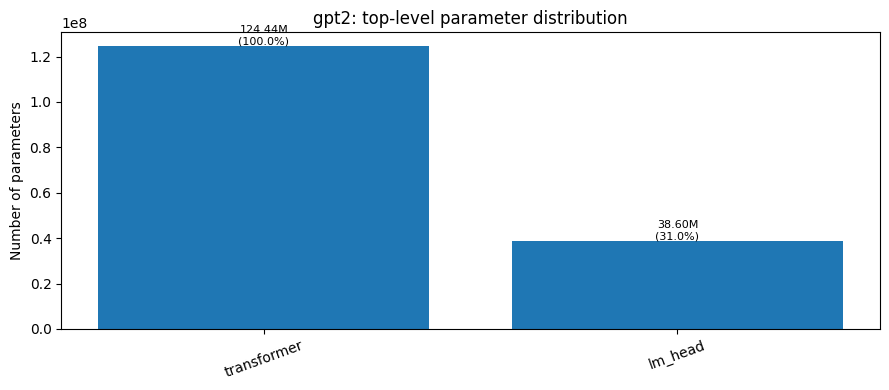

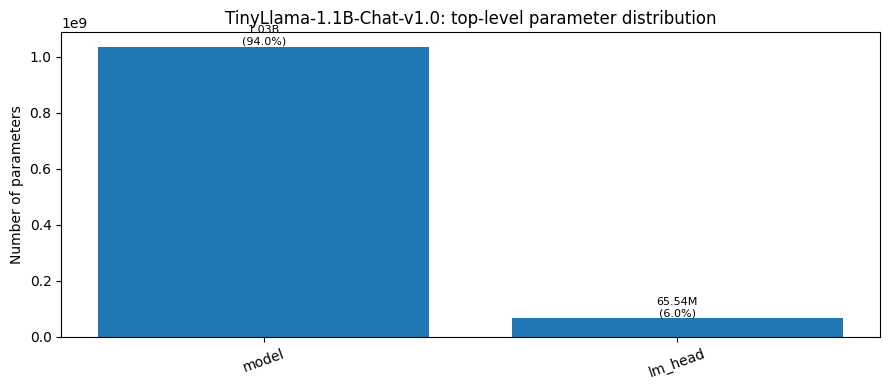

,model_id,model_label,component,component_type,params,share_of_model
0,TinyLlama/TinyLlama-1.1B-Chat-v1.0,TinyLlama-1.1B-Chat-v1.0,model,LlamaModel,1034512384,0.940424
1,TinyLlama/TinyLlama-1.1B-Chat-v1.0,TinyLlama-1.1B-Chat-v1.0,lm_head,Linear,65536000,0.059576
2,openai-community/gpt2,gpt2,transformer,GPT2Model,124439808,1.000000
3,openai-community/gpt2,gpt2,lm_head,Linear,38597376,0.310169


In [72]:
def top_level_param_df(parsed_trees):
    rows = []
    for model_id, tree in parsed_trees.items():
        total = max(tree["num_total_params"], 1)
        for child in tree.get("children", []):
            rows.append({
                "model_id": model_id,
                "model_label": model_label(model_id),
                "component": child["name"],
                "component_type": child["type"],
                "params": child["num_total_params"],
                "share_of_model": child["num_total_params"] / total,
            })
    return pd.DataFrame(rows)

df_top = top_level_param_df({mid: parsed_trees[mid] for mid in model_ids})

for model_name in df_top["model_label"].unique():
    sub = df_top[df_top["model_label"] == model_name].sort_values("params", ascending=False)

    plt.figure(figsize=(9, 4))
    bars = plt.bar(sub["component"], sub["params"])
    plt.title(f"{model_name}: top-level parameter distribution")
    plt.ylabel("Number of parameters")
    plt.xticks(rotation=20)

    for bar, value, share in zip(bars, sub["params"], sub["share_of_model"]):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{format_params(value)}\n({share:.1%})",
            ha="center", va="bottom", fontsize=8
        )

    plt.tight_layout()
    plt.show()

display(df_top.sort_values(["model_label", "params"], ascending=[True, False]).reset_index(drop=True))

###semantic module-count comparison chart

model_label,TinyLlama-1.1B-Chat-v1.0,gpt2
category,,
attention_containers,22,12
attention_projections,88,24
decoder_blocks,22,12
embeddings,2,2
mlp_containers,22,12
mlp_projections,66,24
norms,45,25
positional,0,0


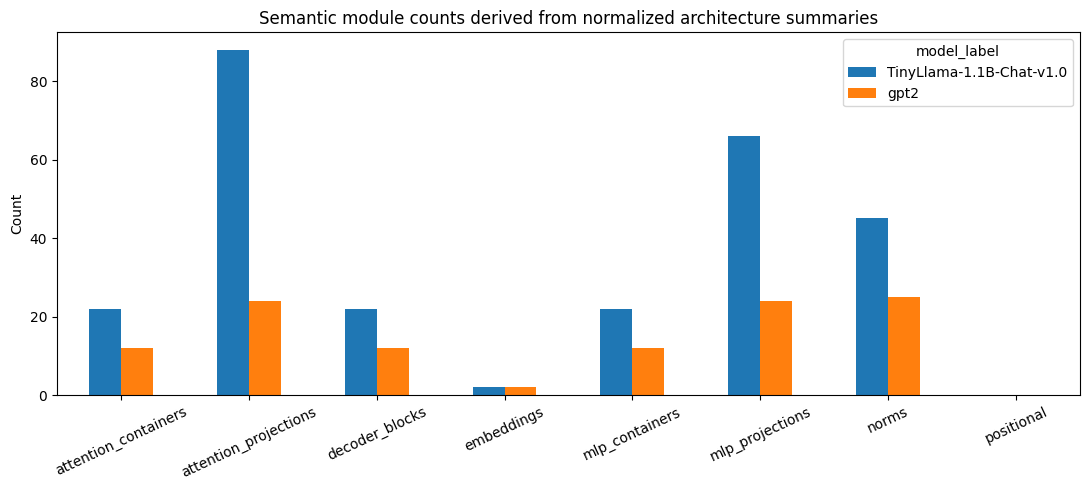

In [73]:
semantic_rows = []

for model_id in model_ids:
    summary = normalized_summaries[model_id]
    semantic_rows.extend([
        {"model_label": model_label(model_id), "category": "embeddings", "count": len(get_embedding_modules(summary))},
        {"model_label": model_label(model_id), "category": "positional", "count": len(get_positional_modules(summary))},
        {"model_label": model_label(model_id), "category": "norms", "count": len(get_norm_modules(summary))},
        {"model_label": model_label(model_id), "category": "attention_containers", "count": len(get_attention_containers(summary))},
        {"model_label": model_label(model_id), "category": "attention_projections", "count": len(get_attention_projections(summary))},
        {"model_label": model_label(model_id), "category": "mlp_containers", "count": len(get_mlp_containers(summary))},
        {"model_label": model_label(model_id), "category": "mlp_projections", "count": len(get_mlp_projections(summary))},
        {"model_label": model_label(model_id), "category": "decoder_blocks", "count": summary.get("num_blocks_detected", 0)},
    ])

df_semantic = pd.DataFrame(semantic_rows)

pivot_semantic = df_semantic.pivot(index="category", columns="model_label", values="count").fillna(0)
display(pivot_semantic)

ax = pivot_semantic.plot(kind="bar", figsize=(11, 5))
ax.set_title("Semantic module counts derived from normalized architecture summaries")
ax.set_ylabel("Count")
ax.set_xlabel("")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

###LoRA target suggestions from the parsed structure

In [74]:
def suggest_lora_targets(summary):
    attn_proj = get_attention_projections(summary)
    mlp_proj = get_mlp_projections(summary)

    # keep only leaf module names (final path component)
    leaf_names = [x.split(".")[-1] for x in attn_proj + mlp_proj]
    leaf_names = list(dict.fromkeys(leaf_names))

    # prioritize commonly adapted projection layers
    preferred = []
    preferred_order = [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "c_attn", "c_proj",
        "gate_proj", "up_proj", "down_proj",
        "c_fc"
    ]
    for name in preferred_order:
        if name in leaf_names:
            preferred.append(name)

    return preferred

df_lora = pd.DataFrame([
    {
        "model_label": model_label(model_id),
        "family": normalized_summaries[model_id].get("family", "unknown"),
        "suggested_lora_targets": ", ".join(suggest_lora_targets(normalized_summaries[model_id]))
    }
    for model_id in model_ids
])

display(df_lora)

,model_label,family,suggested_lora_targets
0,gpt2,gpt2,"c_attn, c_proj, c_fc"
1,TinyLlama-1.1B-Chat-v1.0,llama,"q_proj, k_proj, v_proj, o_proj, gate_proj, up_..."


### Conclusion

Task 1 shows that both models can be parsed into a common hierarchical structure despite belonging to different architecture families. In both cases, the parser successfully recovered the same high-level pattern: embeddings, a repeated decoder block stack, final normalization, and an LM head. This confirms that a reusable parser can abstract away model-specific naming and still produce a clean document-tree style representation.

The comparison also highlights  architectural differences. GPT-2 is a smaller and simpler decoder with 12 repeated `GPT2Block` layers, LayerNorm-based blocks, combined attention projection through `c_attn`, and a two-stage MLP using `c_fc` and `c_proj`.

TinyLlama is much larger, with 22 `LlamaDecoderLayer` blocks, separate `q/k/v/o` attention projections, RMSNorm-style normalization, and a gated MLP using `gate_proj`, `up_proj`, and `down_proj`.



### Task 2 — PEFT/LoRA Fine-Tuning

In [75]:
!pip uninstall -y pyarrow datasets
!pip install -q --no-cache-dir --upgrade pyarrow datasets transformers accelerate peft trl bitsandbytes sentencepiece

Found existing installation: pyarrow 23.0.1
Uninstalling pyarrow-23.0.1:
  Successfully uninstalled pyarrow-23.0.1
Found existing installation: datasets 4.8.4
Uninstalling datasets-4.8.4:
  Successfully uninstalled datasets-4.8.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 314.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 216.9 MB/s eta 0:00:00


In [76]:
import pyarrow
import datasets
from datasets import load_dataset

print("pyarrow:", pyarrow.__version__)
print("datasets:", datasets.__version__)
print("datasets import OK")

pyarrow: 23.0.1
datasets: 4.8.4
datasets import OK


In [77]:
import os
import gc
import json
import time
import random
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    set_seed,
)
from peft import (
    LoraConfig,
    TaskType,
    prepare_model_for_kbit_training,
    get_peft_model,
    PeftModel,
)

assert torch.cuda.is_available(), "This notebook version assumes a CUDA runtime."

set_seed(42)
random.seed(42)
np.random.seed(42)

DEVICE = "cuda"
GPU_NAME = torch.cuda.get_device_name(0)
GPU_MEM_GB = torch.cuda.get_device_properties(0).total_memory / 1024**3
BF16_AVAILABLE = torch.cuda.is_bf16_supported()

print("Device:", DEVICE)
print("GPU:", GPU_NAME)
print(f"GPU memory: {GPU_MEM_GB:.1f} GB")
print("BF16 available:", BF16_AVAILABLE)

Device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
GPU memory: 95.0 GB
BF16 available: True


In [78]:
def load_first_existing(candidate_paths):
    for p in candidate_paths:
        p = Path(p)
        if p.exists():
            with open(p, "r") as f:
                return json.load(f), str(p)
    raise FileNotFoundError(f"None of these files were found: {candidate_paths}")

normalized_summaries, normalized_summaries_path = load_first_existing([
    "normalized_architecture_summaries_clean.json",
    "clean_summaries.json",
    "normalized_architecture_summaries.json"
])

print("Loaded normalized summaries from:", normalized_summaries_path)

MODEL_ID = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
assert MODEL_ID in normalized_summaries, f"{MODEL_ID} not found in Task 1 JSON."
summary = normalized_summaries[MODEL_ID]

print("Selected model:", MODEL_ID)
print("Family:", summary.get("family"))
print("Block container:", summary.get("block_container"))
print("Blocks detected:", summary.get("num_blocks_detected"))

Loaded normalized summaries from: normalized_architecture_summaries.json
Selected model: TinyLlama/TinyLlama-1.1B-Chat-v1.0
Family: llama
Block container: model.layers
Blocks detected: 22


###derive LoRA target modules from Task 1 JSON

In [79]:
def summary_list(summary, key):
    value = summary.get(key, [])
    return value if isinstance(value, list) else []

def get_attention_projections(summary):
    if "attention_projections" in summary:
        return list(dict.fromkeys(summary_list(summary, "attention_projections")))
    old = summary_list(summary, "attention_modules")
    out = []
    for n in old:
        lname = n.lower()
        if lname.endswith(("c_attn", "q_proj", "k_proj", "v_proj", "o_proj")):
            out.append(n)
        elif lname.endswith("c_proj") and (".attn." in lname or ".self_attn." in lname):
            out.append(n)
    return list(dict.fromkeys(out))

attention_projection_paths = get_attention_projections(summary)
TARGET_MODULES = list(dict.fromkeys([x.split(".")[-1] for x in attention_projection_paths]))

print("Attention projection paths recovered by parser:")
for x in attention_projection_paths[:20]:
    print(" ", x)

print("\nLoRA target leaf modules inferred from Task 1 JSON:")
print(TARGET_MODULES)

assert len(TARGET_MODULES) > 0, "No LoRA target modules were inferred from Task 1 JSON."

Attention projection paths recovered by parser:
  model.layers.0.self_attn.q_proj
  model.layers.0.self_attn.k_proj
  model.layers.0.self_attn.v_proj
  model.layers.0.self_attn.o_proj
  model.layers.1.self_attn.q_proj
  model.layers.1.self_attn.k_proj
  model.layers.1.self_attn.v_proj
  model.layers.1.self_attn.o_proj
  model.layers.2.self_attn.q_proj
  model.layers.2.self_attn.k_proj
  model.layers.2.self_attn.v_proj
  model.layers.2.self_attn.o_proj
  model.layers.3.self_attn.q_proj
  model.layers.3.self_attn.k_proj
  model.layers.3.self_attn.v_proj
  model.layers.3.self_attn.o_proj
  model.layers.4.self_attn.q_proj
  model.layers.4.self_attn.k_proj
  model.layers.4.self_attn.v_proj
  model.layers.4.self_attn.o_proj

LoRA target leaf modules inferred from Task 1 JSON:
['q_proj', 'k_proj', 'v_proj', 'o_proj']


###tokenizer and dataset config

In [80]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

MAX_SEQ_LENGTH = 512
TRAIN_SAMPLES = 1500
EVAL_SAMPLES = 300
GEN_EVAL_SAMPLES = 100
NUM_EPOCHS = 3

print("Pad token:", tokenizer.pad_token)
print("Pad token id:", tokenizer.pad_token_id)
print("EOS token id:", tokenizer.eos_token_id)

Pad token: </s>
Pad token id: 2
EOS token id: 2


###IMDB prompt-completion dataset

In [81]:
raw_ds = load_dataset("imdb")

def label_to_text(label):
    return "positive" if int(label) == 1 else "negative"

def truncate_review(text, max_chars=1200):
    text = text.strip()
    return text[:max_chars]

def build_prompt(text):
    review = truncate_review(text)
    return (
        "Classify the sentiment of the following movie review.\n"
        "Answer with exactly one word: positive or negative.\n\n"
        f"Review:\n{review}\n\n"
        "Sentiment:"
    )

train_raw = raw_ds["train"].shuffle(seed=42).select(range(TRAIN_SAMPLES))
eval_raw = raw_ds["test"].shuffle(seed=42).select(range(EVAL_SAMPLES))
gen_eval_raw = raw_ds["test"].shuffle(seed=123).select(range(GEN_EVAL_SAMPLES))

print(train_raw)
print(eval_raw)

Dataset({
    features: ['text', 'label'],
    num_rows: 1500
})
Dataset({
    features: ['text', 'label'],
    num_rows: 300
})


###preprocess into causal-LM training examples

In [82]:
def preprocess_example(example):
    prompt = build_prompt(example["text"])
    completion = " " + label_to_text(example["label"])

    completion_ids = tokenizer(
        completion,
        add_special_tokens=False
    )["input_ids"] + [tokenizer.eos_token_id]

    max_prompt_tokens = MAX_SEQ_LENGTH - len(completion_ids)
    prompt_ids = tokenizer(
        prompt,
        add_special_tokens=False,
        truncation=True,
        max_length=max_prompt_tokens
    )["input_ids"]

    input_ids = prompt_ids + completion_ids
    attention_mask = [1] * len(input_ids)
    labels = [-100] * len(prompt_ids) + completion_ids

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
    }

tokenized_train = train_raw.map(
    preprocess_example,
    remove_columns=train_raw.column_names,
)

tokenized_eval = eval_raw.map(
    preprocess_example,
    remove_columns=eval_raw.column_names,
)

gen_eval = gen_eval_raw.map(
    lambda ex: {
        "prompt": build_prompt(ex["text"]),
        "label_text": label_to_text(ex["label"]),
    },
    remove_columns=gen_eval_raw.column_names,
)

print(tokenized_train[0].keys())
print("Train examples:", len(tokenized_train))
print("Eval examples:", len(tokenized_eval))
print("Generation eval examples:", len(gen_eval))

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

dict_keys(['input_ids', 'attention_mask', 'labels'])
Train examples: 1500
Eval examples: 300
Generation eval examples: 100


###custom collator

In [83]:
class CompletionOnlyCollator:
    def __init__(self, tokenizer):
        self.pad_token_id = tokenizer.pad_token_id

    def __call__(self, features):
        max_len = max(len(f["input_ids"]) for f in features)

        input_ids = []
        attention_mask = []
        labels = []

        for f in features:
            pad_len = max_len - len(f["input_ids"])

            input_ids.append(f["input_ids"] + [self.pad_token_id] * pad_len)
            attention_mask.append(f["attention_mask"] + [0] * pad_len)
            labels.append(f["labels"] + [-100] * pad_len)

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
            "labels": torch.tensor(labels, dtype=torch.long),
        }

data_collator = CompletionOnlyCollator(tokenizer)

###helper functions for generation-based evaluation

In [84]:
def get_model_device(model):
    return next(model.parameters()).device

def extract_label_from_text(text):
    text = text.strip().lower()
    match = re.search(r"\b(positive|negative)\b", text)
    if match:
        return match.group(1)
    return ""

@torch.inference_mode()
def predict_label(model, tokenizer, prompt, max_new_tokens=4):
    was_training = model.training
    model.eval()

    use_cache_before = getattr(model.config, "use_cache", True)
    model.config.use_cache = True

    device = get_model_device(model)
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_SEQ_LENGTH
    ).to(device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        temperature=None,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

    gen_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    raw_text = tokenizer.decode(gen_tokens, skip_special_tokens=True)
    pred = extract_label_from_text(raw_text)

    model.config.use_cache = use_cache_before
    if was_training:
        model.train()

    return pred, raw_text

def evaluate_generation_accuracy(model, tokenizer, dataset):
    rows = []
    for ex in dataset:
        pred, raw = predict_label(model, tokenizer, ex["prompt"])
        rows.append({
            "reference": ex["label_text"],
            "prediction": pred,
            "raw_generation": raw,
            "correct": pred == ex["label_text"],
        })

    df = pd.DataFrame(rows)
    acc = df["correct"].mean() if len(df) else 0.0
    return acc, df

###load TinyLlama in 4-bit and measure baseline

In [85]:
COMPUTE_DTYPE = torch.bfloat16 if BF16_AVAILABLE else torch.float16

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
)

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=quant_config,
    torch_dtype=COMPUTE_DTYPE,
    low_cpu_mem_usage=True,
)

if get_model_device(base_model).type != "cuda":
    base_model = base_model.to("cuda")

base_model.config.pad_token_id = tokenizer.pad_token_id
base_model.config.use_cache = False

print("Model device:", get_model_device(base_model))
print("4-bit base model loaded.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model device: cuda:0
4-bit base model loaded.


###baseline evaluation before LoRA

In [86]:
baseline_acc, baseline_preds = evaluate_generation_accuracy(
    base_model,
    tokenizer,
    gen_eval,
)

print(f"Baseline generation accuracy: {baseline_acc:.4f}")
baseline_preds.head(10)

Both `max_new_tokens` (=4) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Baseline generation accuracy: 0.7200


,reference,prediction,raw_generation,correct
0,positive,positive,Positive\n\n,True
1,negative,negative,Negative\n\n,True
2,negative,negative,Negative\n\n,True
3,positive,positive,Positive\n\n,True
4,positive,positive,Positive\n\n,True
5,negative,positive,Positive\n\n,False
6,positive,positive,Positive\n\n,True
7,positive,positive,Positive\n\n,True
8,positive,positive,Positive\n\n,True
9,negative,negative,Negative\n\n,True


###prepare model for k-bit training and attach LoRA

In [91]:
lora_r = 16
lora_alpha = 32
lora_dropout = 0.05

# prepare_model_for_kbit_training enables gradient checkpointing by default.
model = prepare_model_for_kbit_training(base_model)

# Explicitly disable it since we have 95GB RAM and it is causing errors.
model.gradient_checkpointing_disable()

lora_config = LoraConfig(
    r=lora_r,
    lora_alpha=lora_alpha,
    lora_dropout=lora_dropout,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
    target_modules=TARGET_MODULES,
)

model = get_peft_model(model, lora_config)
model.config.pad_token_id = tokenizer.pad_token_id
model.config.use_cache = False

model.print_trainable_parameters()

trainable params: 4,505,600 || all params: 1,104,553,984 || trainable%: 0.4079


/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


###training arguments

In [92]:
OUTPUT_DIR = "task2_task3_tinyllama_imdb_lora"

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=1,
    learning_rate=2e-4,
    logging_steps=50,

    save_strategy="epoch",
    save_total_limit=1,
    report_to="none",
    bf16=BF16_AVAILABLE,
    fp16=not BF16_AVAILABLE,
    optim="paged_adamw_8bit",
    gradient_checkpointing=False,
    warmup_ratio=0.03,
    lr_scheduler_type="linear",
    weight_decay=0.0,
    remove_unused_columns=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval,
    data_collator=data_collator,
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [93]:
start_time = time.time()
train_output = trainer.train()
train_runtime_min = (time.time() - start_time) / 60

train_metrics = train_output.metrics
train_metrics["train_runtime_minutes_wallclock"] = train_runtime_min

print(train_metrics)

eval_metrics = trainer.evaluate()
print(eval_metrics)

Step,Training Loss
50,0.302445
100,0.090611
150,0.081742
200,0.059089
250,0.032725


{'train_runtime': 70.0042, 'train_samples_per_second': 64.282, 'train_steps_per_second': 4.028, 'total_flos': 1.021795221897216e+16, 'train_loss': 0.10528437423367873, 'epoch': 3.0, 'train_runtime_minutes_wallclock': 1.1717836380004882}


RuntimeError: on_train_begin must be called before on_evaluate

In [94]:
adapter_acc, adapter_preds = evaluate_generation_accuracy(
    trainer.model,
    tokenizer,
    gen_eval,
)

print(f"LoRA adapter generation accuracy: {adapter_acc:.4f}")
adapter_preds.head(10)

Both `max_new_tokens` (=4) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

LoRA adapter generation accuracy: 0.9300


,reference,prediction,raw_generation,correct
0,positive,positive,positive,True
1,negative,negative,negative,True
2,negative,negative,negative,True
3,positive,positive,positive,True
4,positive,positive,positive,True
5,negative,negative,negative,True
6,positive,positive,positive,True
7,positive,positive,positive,True
8,positive,positive,positive,True
9,negative,negative,negative,True


In [95]:
ADAPTER_DIR = os.path.join(OUTPUT_DIR, "lora_adapter")
trainer.model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

print("Saved adapter to:", ADAPTER_DIR)

Saved adapter to: task2_task3_tinyllama_imdb_lora/lora_adapter


#Task 3 — merge adapter back into the base model

###free memory before merge

In [96]:
del trainer
del model
del base_model
gc.collect()
torch.cuda.empty_cache()

print("Freed training objects from memory.")

Freed training objects from memory.


###reload base model in FP16/BF16 for merge

In [97]:
merge_dtype = torch.bfloat16 if BF16_AVAILABLE else torch.float16

merge_base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=merge_dtype,
    low_cpu_mem_usage=True,
).to("cuda")

merge_base_model.config.pad_token_id = tokenizer.pad_token_id
merge_base_model.config.use_cache = False

print("Reloaded base model for merge on device:", get_model_device(merge_base_model))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Reloaded base model for merge on device: cuda:0


###load adapter and merge

In [99]:
!pip install -q --upgrade torchao

peft_model_for_merge = PeftModel.from_pretrained(
    merge_base_model,
    ADAPTER_DIR,
)

merged_model = peft_model_for_merge.merge_and_unload()
merged_model.config.pad_token_id = tokenizer.pad_token_id
merged_model.config.use_cache = False
merged_model.eval()

print("Merged model type:", type(merged_model))
print("Merged model device:", get_model_device(merged_model))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 72.2 MB/s eta 0:00:00


Merged model type: <class 'transformers.models.llama.modeling_llama.LlamaForCausalLM'>
Merged model device: cuda:0


###evaluate merged model

In [100]:
merged_acc, merged_preds = evaluate_generation_accuracy(
    merged_model,
    tokenizer,
    gen_eval,
)

print(f"Merged model generation accuracy: {merged_acc:.4f}")
merged_preds.head(10)

Both `max_new_tokens` (=4) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Merged model generation accuracy: 0.9400


,reference,prediction,raw_generation,correct
0,positive,positive,positive,True
1,negative,negative,negative,True
2,negative,negative,negative,True
3,positive,positive,positive,True
4,positive,positive,positive,True
5,negative,negative,negative,True
6,positive,positive,positive,True
7,positive,positive,positive,True
8,positive,positive,positive,True
9,negative,negative,negative,True


###save merged model

In [101]:
MERGED_DIR = os.path.join(OUTPUT_DIR, "merged_model")
merged_model.save_pretrained(MERGED_DIR)
tokenizer.save_pretrained(MERGED_DIR)

print("Saved merged model to:", MERGED_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved merged model to: task2_task3_tinyllama_imdb_lora/merged_model


###comparison table

In [103]:
results_table = pd.DataFrame([
    {
        "model_state": "base_model_before_lora",
        "generation_accuracy": baseline_acc,
    },
    {
        "model_state": "lora_adapter_after_training",
        "generation_accuracy": adapter_acc,
    },
    {
        "model_state": "merged_model_after_task3",
        "generation_accuracy": merged_acc,
    },
])

# Safely check for training metrics existence
if "train_metrics" in locals() and "train_loss" in train_metrics:
    results_table["train_loss"] = [None, train_metrics["train_loss"], None]

# Safely check for eval metrics existence to avoid the NameError
if "eval_metrics" in locals() and "eval_loss" in eval_metrics:
    results_table["eval_loss"] = [None, eval_metrics["eval_loss"], None]

results_table

,model_state,generation_accuracy,train_loss
0,base_model_before_lora,0.72,NaN
1,lora_adapter_after_training,0.93,0.105284
2,merged_model_after_task3,0.94,NaN


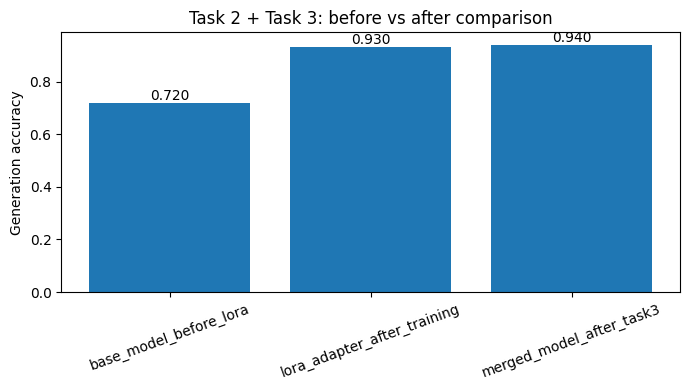

In [104]:
plt.figure(figsize=(7, 4))
bars = plt.bar(results_table["model_state"], results_table["generation_accuracy"])
plt.ylabel("Generation accuracy")
plt.title("Task 2 + Task 3: before vs after comparison")
plt.xticks(rotation=20)

for bar, value in zip(bars, results_table["generation_accuracy"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

###side-by-side sample predictions

In [105]:
sample_count = 12
sample_prompts = [gen_eval[i]["prompt"] for i in range(sample_count)]
sample_refs = [gen_eval[i]["label_text"] for i in range(sample_count)]

comparison_rows = []
for i, (prompt, ref) in enumerate(zip(sample_prompts, sample_refs)):
    base_pred, base_raw = predict_label(merge_base_model, tokenizer, prompt)
    # merge_base_model no longer exists as an unadapted model after merge loading logic.
    # reload a lightweight base model handle for fair side-by-side generation:
    comparison_rows.append({
        "idx": i,
        "reference": ref,
        "base_prediction": None,
        "adapter_prediction": adapter_preds.iloc[i]["prediction"] if i < len(adapter_preds) else None,
        "merged_prediction": merged_preds.iloc[i]["prediction"] if i < len(merged_preds) else None,
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

Both `max_new_tokens` (=4) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

,idx,reference,base_prediction,adapter_prediction,merged_prediction
0,0,positive,None,positive,positive
1,1,negative,None,negative,negative
2,2,negative,None,negative,negative
3,3,positive,None,positive,positive
4,4,positive,None,positive,positive
5,5,negative,None,negative,negative
6,6,positive,None,positive,positive
7,7,positive,None,positive,positive
8,8,positive,None,positive,positive
9,9,negative,None,negative,negative


###reload clean base model for exact side-by-side samples

In [106]:
gc.collect()
torch.cuda.empty_cache()

base_for_samples = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=quant_config,
    torch_dtype=COMPUTE_DTYPE,
    low_cpu_mem_usage=True,
)

if get_model_device(base_for_samples).type != "cuda":
    base_for_samples = base_for_samples.to("cuda")

base_for_samples.config.pad_token_id = tokenizer.pad_token_id
base_for_samples.config.use_cache = False

sample_rows = []
for i in range(min(12, len(gen_eval))):
    prompt = gen_eval[i]["prompt"]
    ref = gen_eval[i]["label_text"]

    base_pred, base_raw = predict_label(base_for_samples, tokenizer, prompt)
    merged_pred, merged_raw = predict_label(merged_model, tokenizer, prompt)

    sample_rows.append({
        "idx": i,
        "reference": ref,
        "base_prediction": base_pred,
        "merged_prediction": merged_pred,
        "base_raw_generation": base_raw,
        "merged_raw_generation": merged_raw,
    })

sample_df = pd.DataFrame(sample_rows)
sample_df

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Both `max_new_tokens` (=4) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=4) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

,idx,reference,base_prediction,merged_prediction,base_raw_generation,merged_raw_generation
0,0,positive,positive,positive,Positive\n\n,positive
1,1,negative,negative,negative,Negative\n\n,negative
2,2,negative,negative,negative,Negative\n\n,negative
3,3,positive,positive,positive,Positive\n\n,positive
4,4,positive,positive,positive,Positive\n\n,positive
5,5,negative,positive,negative,Positive\n\n,negative
6,6,positive,positive,positive,Positive\n\n,positive
7,7,positive,positive,positive,Positive\n\n,positive
8,8,positive,positive,positive,Positive\n\n,positive
9,9,negative,negative,negative,Negative\n\n,negative


###adapter vs merged consistency check

In [108]:
adapter_vs_merged = pd.DataFrame({
    "reference": adapter_preds["reference"],
    "adapter_prediction": adapter_preds["prediction"],
    "merged_prediction": merged_preds["prediction"],
})

adapter_vs_merged["same_prediction"] = (
    adapter_vs_merged["adapter_prediction"] == adapter_vs_merged["merged_prediction"]
)

adapter_vs_merged_match_rate = adapter_vs_merged["same_prediction"].mean()

print(f"Adapter vs merged prediction match rate: {adapter_vs_merged_match_rate:.4f}")
adapter_vs_merged.head(5)

Adapter vs merged prediction match rate: 0.9700


,reference,adapter_prediction,merged_prediction,same_prediction
0,positive,positive,positive,True
1,negative,negative,negative,True
2,negative,negative,negative,True
3,positive,positive,positive,True
4,positive,positive,positive,True


In [110]:
run_summary = pd.DataFrame([{
    "model_id": MODEL_ID,
    "gpu": GPU_NAME,
    "gpu_memory_gb": round(GPU_MEM_GB, 1),
    "train_samples": TRAIN_SAMPLES,
    "eval_samples": EVAL_SAMPLES,
    "generation_eval_samples": GEN_EVAL_SAMPLES,
    "epochs": NUM_EPOCHS,
    "max_seq_length": MAX_SEQ_LENGTH,
    "target_modules_from_parser": ", ".join(TARGET_MODULES),
    "baseline_generation_accuracy": baseline_acc,
    "adapter_generation_accuracy": adapter_acc,
    "merged_generation_accuracy": merged_acc,
    "adapter_vs_merged_match_rate": adapter_vs_merged_match_rate,
    "train_loss": train_metrics.get("train_loss"),
    "eval_loss": locals().get("eval_metrics", {}).get("eval_loss"),
    "train_runtime_minutes_wallclock": train_metrics.get("train_runtime_minutes_wallclock"),
}])

run_summary

,model_id,gpu,gpu_memory_gb,train_samples,eval_samples,generation_eval_samples,epochs,max_seq_length,target_modules_from_parser,baseline_generation_accuracy,adapter_generation_accuracy,merged_generation_accuracy,adapter_vs_merged_match_rate,train_loss,eval_loss,train_runtime_minutes_wallclock
0,TinyLlama/TinyLlama-1.1B-Chat-v1.0,NVIDIA RTX PRO 6000 Blackwell Server Edition,95.0,1500,300,100,3,512,"q_proj, k_proj, v_proj, o_proj",0.72,0.93,0.94,0.97,0.105284,None,1.171784
